# Pipeline de Procesamiento de Datos y Modelado Descriptivo para el Sector Gastronómico

Este notebook presenta el flujo de trabajo final para el procesamiento y análisis de ~1.8M de reseñas de Google Maps. La arquitectura utiliza checkpoints en formato Parquet para garantizar la eficiencia y reproducibilidad.

## 3. Materiales y Métodos

{Procesamiento de datos}
Se utilizó Python con la librería `Pandas` y el motor `PyArrow` para el manejo eficiente de los archivos CSV originales, permitiendo una transición fluida hacia el formato Parquet.

In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from matplotlib.colors import LogNorm

# Descargas necesarias para NLP
nltk.download(['stopwords', 'wordnet', 'omw-1.4', 'punkt', 'punkt_tab'], quiet=True)

def run_data_ingestion(input_path: str) -> pd.DataFrame:
    """
    Carga inicial y generación del checkpoint original.
    """
    df = pd.read_csv(input_path)
    df.to_parquet('reviews_step0_raw.parquet', index=False)
    return df

{Limpieza y Transformación}
Se aplicaron protocolos de tratamiento de nulos, deduplicación por `id_review` y estandarización de texto (minúsculas y remoción de caracteres especiales).

In [8]:
def process_pipeline(input_parquet: str) -> pd.DataFrame:
    """
    Pipeline integral: Limpieza + Feature Engineering conservando coordenadas.
    """
    df = pd.read_parquet(input_parquet)

    # 1. Limpieza
    df['caption'] = df['caption'].fillna('')
    df = df.drop_duplicates(subset=['id_review'])
    df['caption_clean'] = df['caption'].apply(lambda x: re.sub(r'[^a-záéíóúñ0-9\s]', '', str(x).lower()).strip())

    # 2. Transformación
    df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')
    df['text_len'] = df['caption'].str.len()
    df['word_count'] = df['caption'].apply(lambda x: len(str(x).split()))
    df['rating_category'] = pd.cut(df['rating'], bins=[0, 2, 3, 5], labels=['Baja', 'Media', 'Alta'])

    return df

In [15]:
import re
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import SnowballStemmer

def process_pipeline(input_parquet: str) -> pd.DataFrame:
    """
    Pipeline integral: Limpieza + NLP Feature Engineering conservando coordenadas.
    Incluye remoción real de stopwords y Stemming para español.
    """
    df = pd.read_parquet(input_parquet)

    # 1. Limpieza Estructural
    df['caption'] = df['caption'].fillna('')
    df = df.drop_duplicates(subset=['id_review'])

    # 2. Configuración de NLP para Español
    stop_words_sp = set(stopwords.words('spanish'))
    # Agregamos ruido común en reseñas que no aporta valor a los tópicos
    stop_words_sp.update(['si', 'q', 'que', 'mas', 'más', 'ser', 'hacer', 'ir', 'lugar', 'sitio', 'vez', 'asi'])

    stemmer = SnowballStemmer('spanish')

    # 3. Función interna de NLP (Vectorizada con .apply)
    def clean_text_nlp(text):
        # A. Limpieza básica (minúsculas y solo alfanuméricos)
        text = re.sub(r'[^a-záéíóúñ0-9\s]', '', str(text).lower()).strip()

        # B. Tokenización por espacios
        tokens = text.split()

        # C. Filtrado de Stopwords y Stemming (Derivación)
        # Solo conservamos palabras de más de 2 caracteres
        cleaned_tokens = [stemmer.stem(word) for word in tokens if word not in stop_words_sp and len(word) > 2]

        # D. Reconstrucción del texto
        return " ".join(cleaned_tokens)

    # Aplicamos el motor NLP
    print("Aplicando procesamiento NLP (Stopwords + Stemming). Esto puede tomar unos minutos...")
    df['caption_clean'] = df['caption'].apply(clean_text_nlp)

    # 4. Transformación de Variables Estructurales
    df['review_date'] = pd.to_datetime(df['review_date'], errors='coerce')
    df['text_len'] = df['caption'].str.len()
    df['word_count'] = df['caption'].apply(lambda x: len(str(x).split()))
    df['rating_category'] = pd.cut(df['rating'], bins=[0, 2, 3, 5], labels=['Baja', 'Media', 'Alta'])

    return df

## 3 y 4. Modelado Descriptivo: métodos y resultados

{Análisis Espacial y Temporal}

Integración de datos georeferenciados y evolución de métricas de satisfacción.

In [3]:
def generate_visualizations(df_final: pd.DataFrame, geojson_path: str):
    """
    Generación de visualizaciones de estándar académico.
    """
    # A. Engagement Semanal
    df_final['day_of_week'] = df_final['review_date'].dt.day_name()
    day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    day_counts = df_final['day_of_week'].value_counts().reindex(day_order)

    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x=day_counts.index, y=day_counts.values, palette='Blues_d', hue=day_counts.index, legend=False)
    plt.axhline(day_counts.mean(), color='red', linestyle='--', label=f'Promedio: {int(day_counts.mean()):,}')
    plt.title('Engagement Semanal: Volumen Total de Reseñas', fontsize=14, fontweight='bold')
    plt.show()

    # B. Mapa Coroplético (Si existe el archivo geojson)
    try:
        peru = gpd.read_file(geojson_path)
        # Aquí se realizaría el sjoin y plot con LogNorm
        print("Mapa base cargado. Proceder con análisis geo-espacial.")
    except Exception as e:
        print(f"GeoJSON no disponible para visualización automática: {e}")

### Ejecución del Flujo Completo
Paso 0 -> Paso 1 -> Análisis Final.

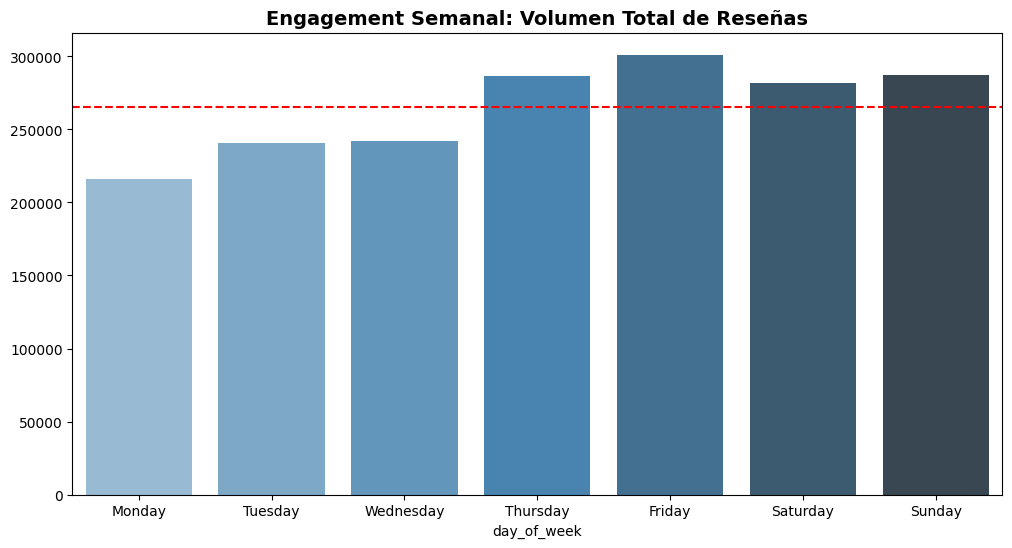

Mapa base cargado. Proceder con análisis geo-espacial.


In [33]:
# 1. Ingesta
df_raw = run_data_ingestion('/content/reviews_raw.csv')

# 2. Procesamiento
df_final = process_pipeline('reviews_step0_raw.parquet')

# CORRECCIÓN DE COMPATIBILIDAD PARA SPARK:
# Forzamos la resolución de nanosegundos a microsegundos en el archivo Parquet
df_final.to_parquet('reviews_final_processed.parquet', index=False, allow_truncated_timestamps=True, coerce_timestamps='us')

# 3. Visualización
generate_visualizations(df_final, '/content/peru_departamental_simple.geojson')

### Análisis de Engagement Temporal
Visualización de la evolución del volumen de reseñas y patrones de comportamiento semanal.

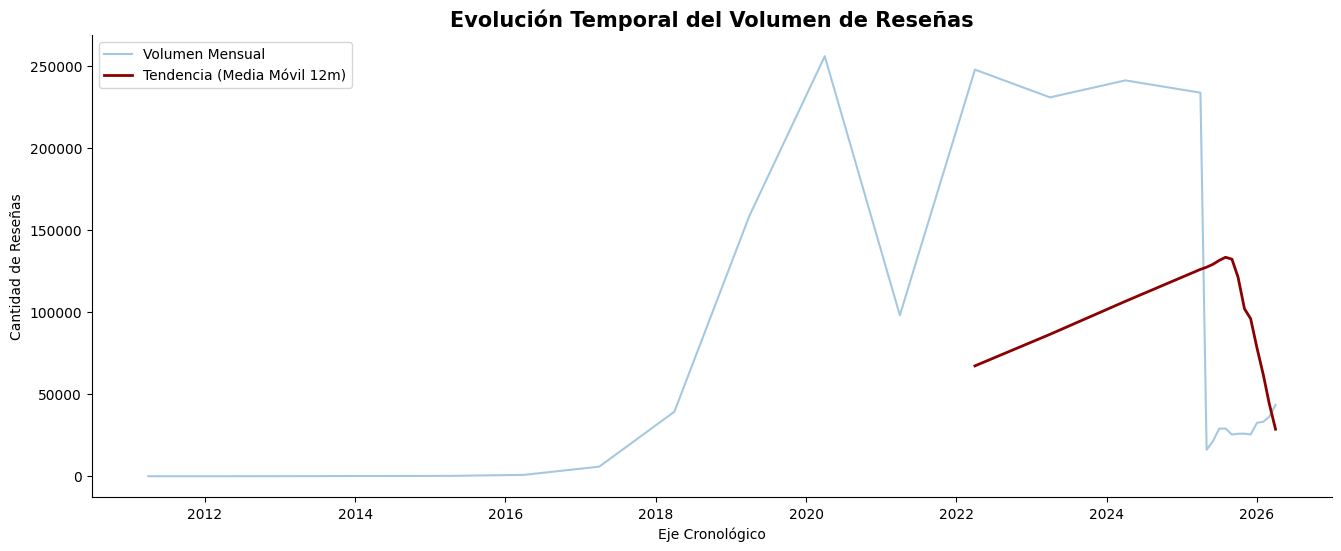

In [5]:
# A. Evolución Temporal (Volumen Mensual con Línea de Tendencia)
temporal_dist = df_final.groupby(df_final['review_date'].dt.to_period('M')).size().reset_index(name='count')
temporal_dist['year_month_dt'] = temporal_dist['review_date'].dt.to_timestamp()
temporal_dist['rolling_avg'] = temporal_dist['count'].rolling(window=12).mean()

plt.figure(figsize=(16, 6))
sns.lineplot(data=temporal_dist, x='year_month_dt', y='count', alpha=0.4, label='Volumen Mensual')
sns.lineplot(data=temporal_dist, x='year_month_dt', y='rolling_avg', color='darkred', linewidth=2, label='Tendencia (Media Móvil 12m)')
plt.title('Evolución Temporal del Volumen de Reseñas', fontsize=15, fontweight='bold')
plt.xlabel('Eje Cronológico')
plt.ylabel('Cantidad de Reseñas')
plt.legend()
sns.despine()
plt.show()

### Análisis Geográfico Regional
Uso de mapas coropléticos para identificar la densidad de la oferta gastronómica y la satisfacción del cliente por departamento.

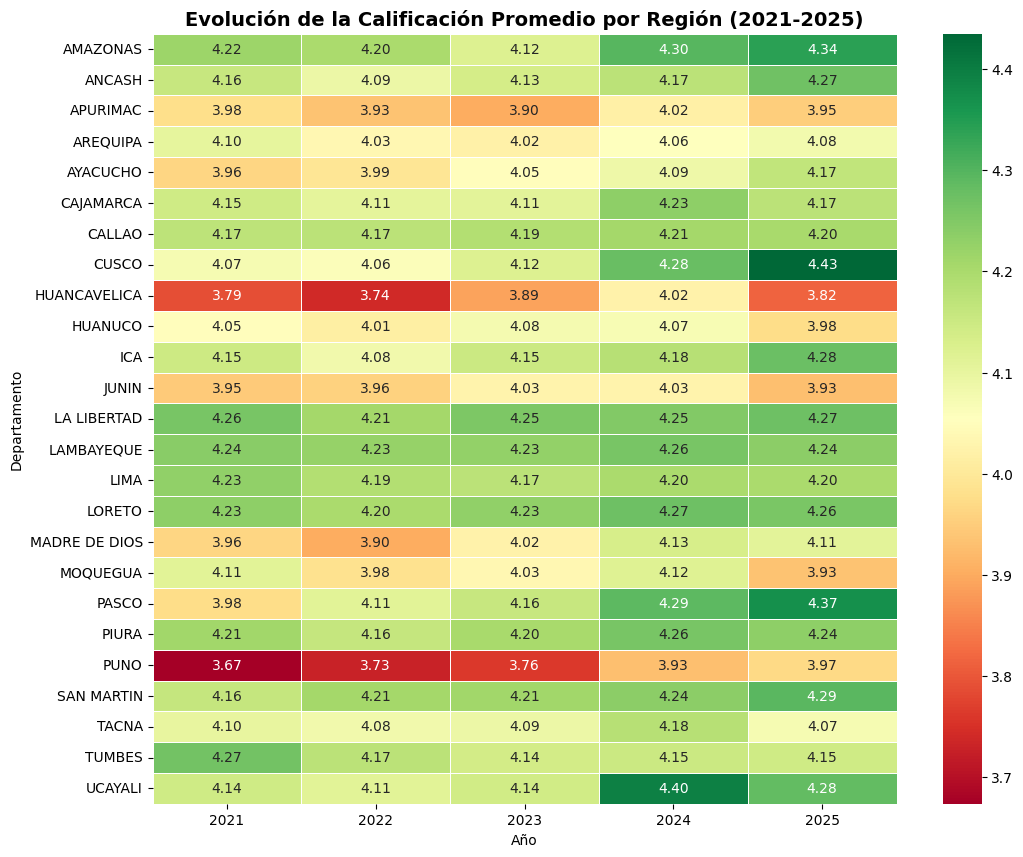

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt
import geopandas as gpd
import pandas as pd

# 1. Cargar coordenadas desde el archivo de locales (peru.csv)
df_places = pd.read_csv('/content/peru.csv')

# Procesar la columna 'coor' (formato 'lat, lng')
df_places = df_places.dropna(subset=['coor'])
coords = df_places['coor'].str.split(',', expand=True)
df_places['latitude'] = coords[0].astype(float)
df_places['longitude'] = coords[1].astype(float)

# 2. Unir con df_final usando 'place_id'
# Nota: En peru.csv la columna es 'id'
df_geo = df_final.merge(df_places[['id', 'latitude', 'longitude']], left_on='place_id', right_on='id', how='inner')

# 3. Crear GeoDataFrame y unir con departamentos
peru_map = gpd.read_file('/content/peru_departamental_simple.geojson')
gdf_reviews = gpd.GeoDataFrame(
    df_geo,
    geometry=gpd.points_from_xy(df_geo.longitude, df_geo.latitude),
    crs='EPSG:4326'
)

# Join espacial para asignar departamento a cada reseña
gdf_reviews_filtered = gpd.sjoin(gdf_reviews, peru_map[['NOMBDEP', 'geometry']], predicate='within')

# 4. Generar Heatmap Regional (2021-2024)
gdf_reviews_filtered['year'] = gdf_reviews_filtered['review_date'].dt.year
df_heatmap = gdf_reviews_filtered[gdf_reviews_filtered['year'].isin([2021, 2022, 2023, 2024, 2025])]
heatmap_data = df_heatmap.pivot_table(index='NOMBDEP', columns='year', values='rating', aggfunc='mean')

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data, annot=True, fmt=".2f", cmap="RdYlGn", linewidths=0.5)
plt.title('Evolución de la Calificación Promedio por Región (2021-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Año')
plt.ylabel('Departamento')
plt.show()

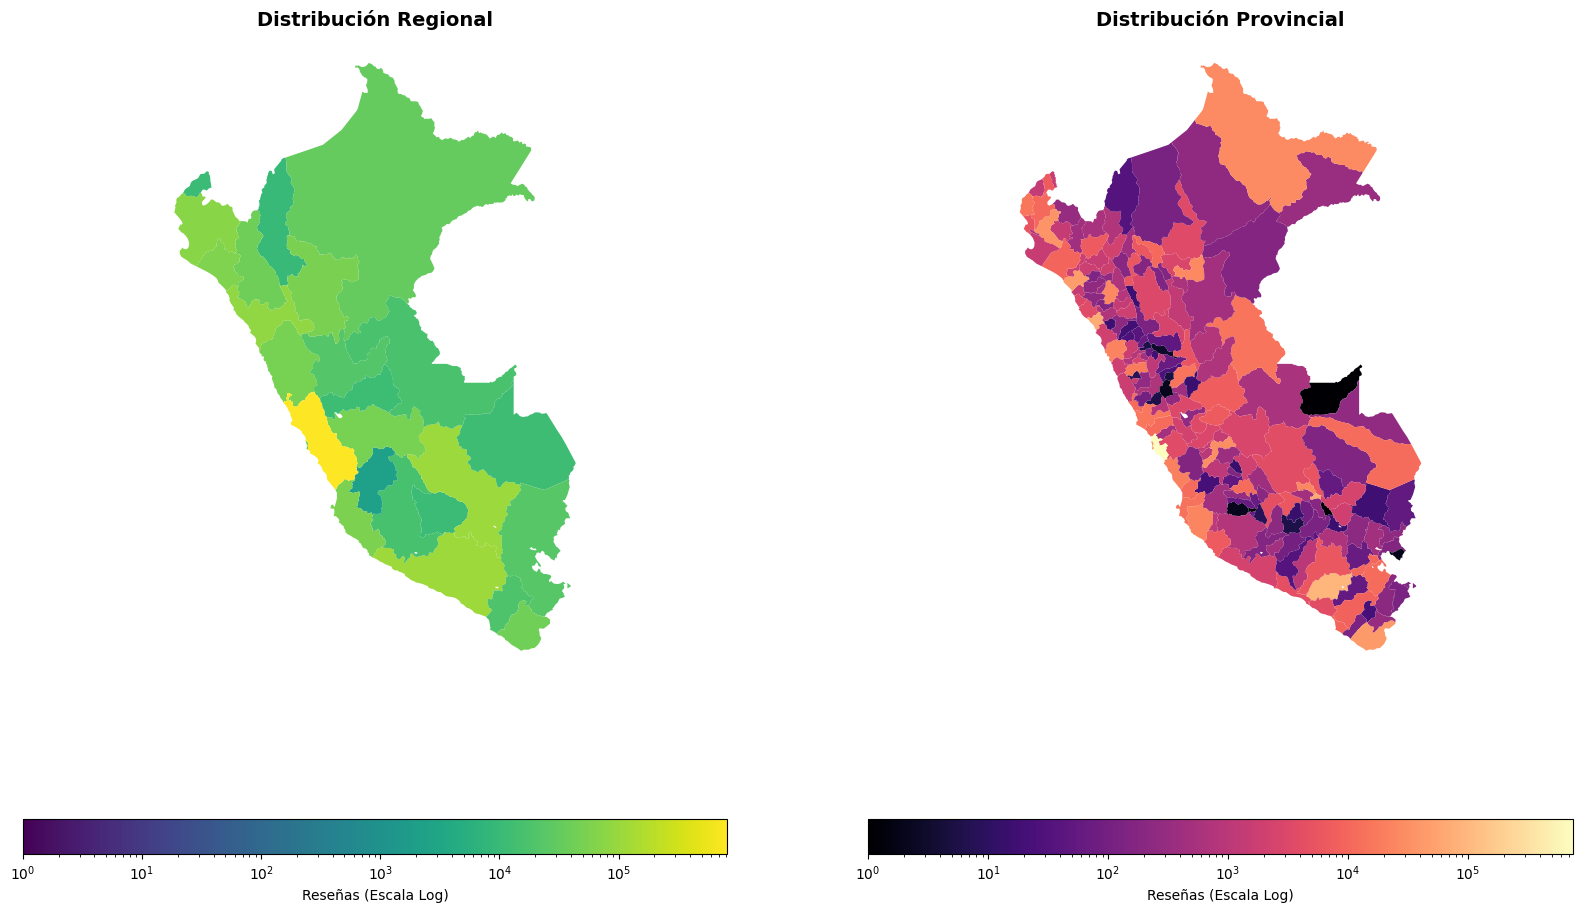

In [20]:
# B. Mapas Coropléticos con Escala Logarítmica
import matplotlib.colors as colors
import geopandas as gpd

# 1. Preparar datos para Departamento
dep_counts = gdf_reviews_filtered.groupby('NOMBDEP').size().reset_index(name='review_count')
dep_map = peru_map.merge(dep_counts, on='NOMBDEP', how='left').fillna({'review_count': 1})

# 2. Cargar y preparar datos para Provincia
prov_map_base = gpd.read_file('/content/peru_provincial_simple.geojson')
# Unimos espacialmente las reseñas con las provincias
gdf_prov = gpd.sjoin(gdf_reviews, prov_map_base[['NOMBPROV', 'geometry']], predicate='within')
prov_counts = gdf_prov.groupby('NOMBPROV').size().reset_index(name='review_count')
prov_map = prov_map_base.merge(prov_counts, on='NOMBPROV', how='left').fillna({'review_count': 1})

fig, ax = plt.subplots(1, 2, figsize=(20, 12))

# Visualización Departamento
dep_map.plot(column='review_count', ax=ax[0], legend=True, cmap='viridis',
             norm=colors.LogNorm(vmin=1, vmax=dep_map['review_count'].max()),
             legend_kwds={'label': 'Reseñas (Escala Log)', 'orientation': 'horizontal'})
ax[0].set_title('Distribución Regional', fontsize=14, fontweight='bold')
ax[0].axis('off')

# Visualización Provincia
prov_map.plot(column='review_count', ax=ax[1], legend=True, cmap='magma',
              norm=colors.LogNorm(vmin=1, vmax=prov_map['review_count'].max()),
              legend_kwds={'label': 'Reseñas (Escala Log)', 'orientation': 'horizontal'})
ax[1].set_title('Distribución Provincial', fontsize=14, fontweight='bold')
ax[1].axis('off')

plt.show()

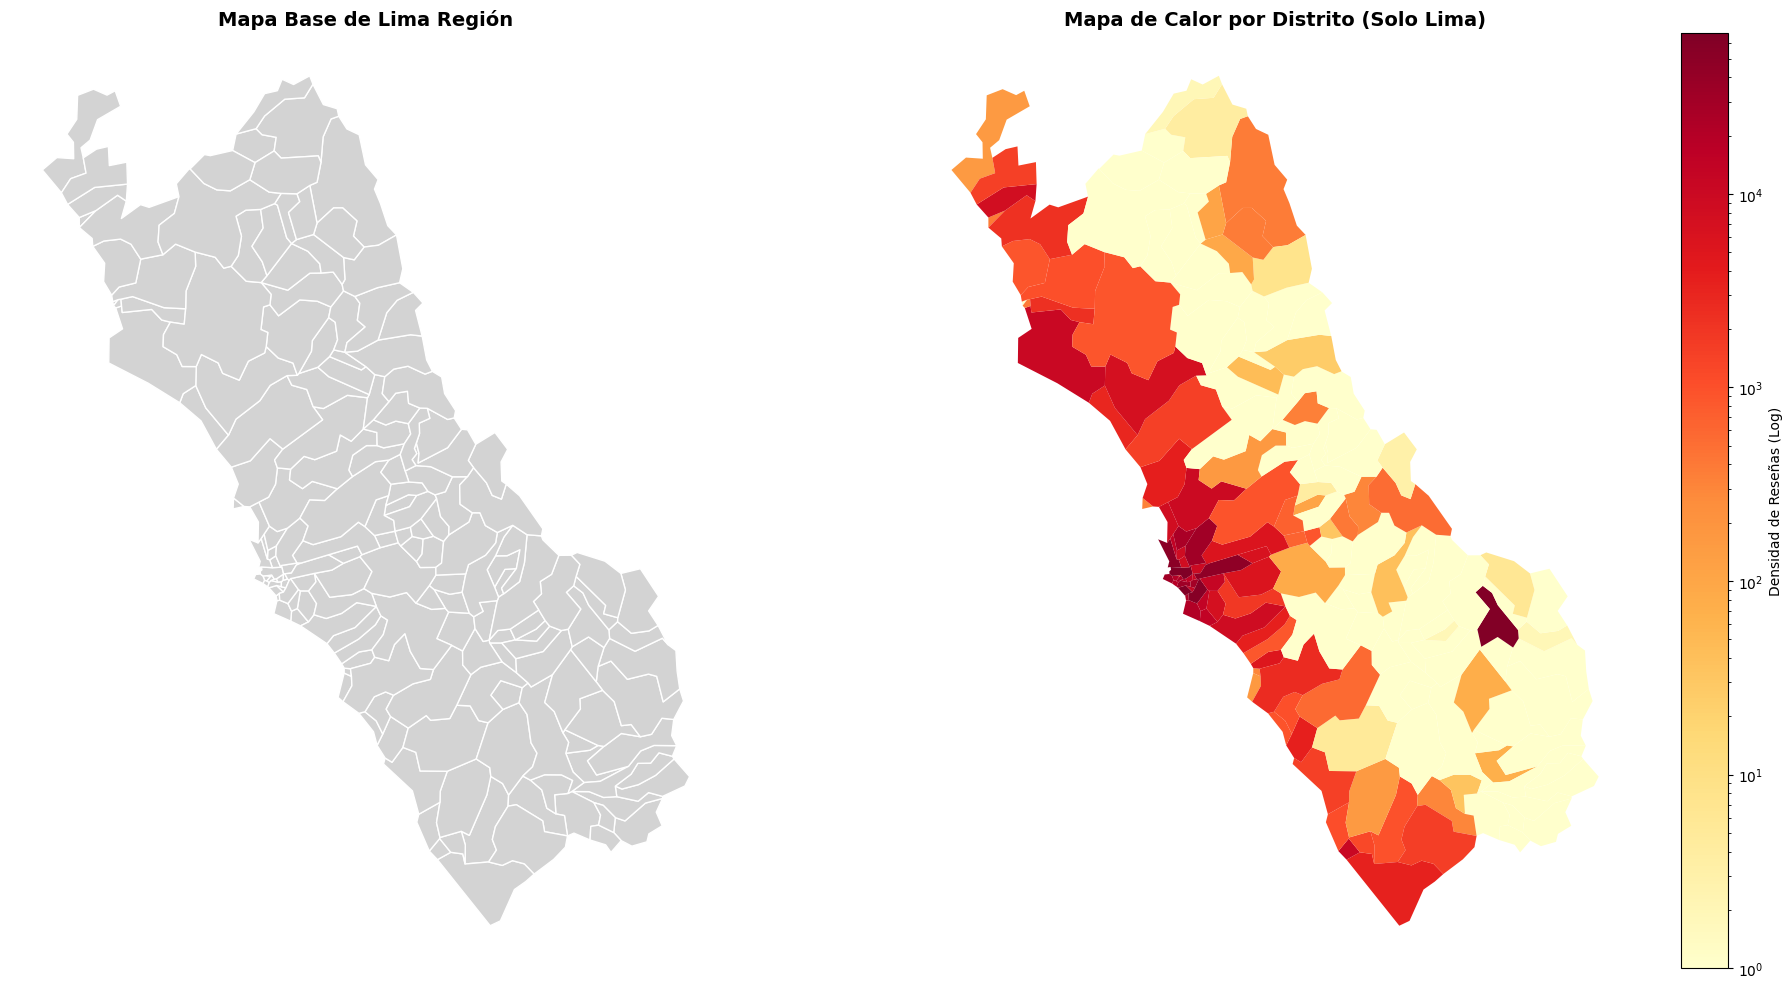

In [19]:
import matplotlib.colors as colors
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Cargar el mapa distrital y filtrar solo para Lima
# Se asume que en peru_distrital_simple.geojson el departamento está en 'NOMBDEP'
lima_distritos = gpd.read_file('/content/peru_distrital_simple.geojson')
lima_distritos = lima_distritos[lima_distritos['NOMBDEP'] == 'LIMA']

# 2. Unir espacialmente las reseñas con los distritos de Lima
gdf_lima_reviews = gpd.sjoin(gdf_reviews, lima_distritos[['NOMBDIST', 'geometry']], predicate='within')

# 3. Contar reseñas por distrito
dist_counts = gdf_lima_reviews.groupby('NOMBDIST').size().reset_index(name='review_count')
lima_map_data = lima_distritos.merge(dist_counts, on='NOMBDIST', how='left').fillna({'review_count': 1})

# 4. Graficar
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# Mapa de Lima Departamento (Base)
lima_distritos.plot(ax=ax[0], color='lightgrey', edgecolor='white')
ax[0].set_title('Mapa Base de Lima Región', fontsize=14, fontweight='bold')
ax[0].axis('off')

# Mapa de Calor por Distrito
lima_map_data.plot(column='review_count', ax=ax[1], legend=True, cmap='YlOrRd',
                  norm=colors.LogNorm(vmin=1, vmax=lima_map_data['review_count'].max()),
                  legend_kwds={'label': 'Densidad de Reseñas (Log)', 'orientation': 'vertical'})
ax[1].set_title('Mapa de Calor por Distrito (Solo Lima)', fontsize=14, fontweight='bold')
ax[1].axis('off')

plt.tight_layout()
plt.show()

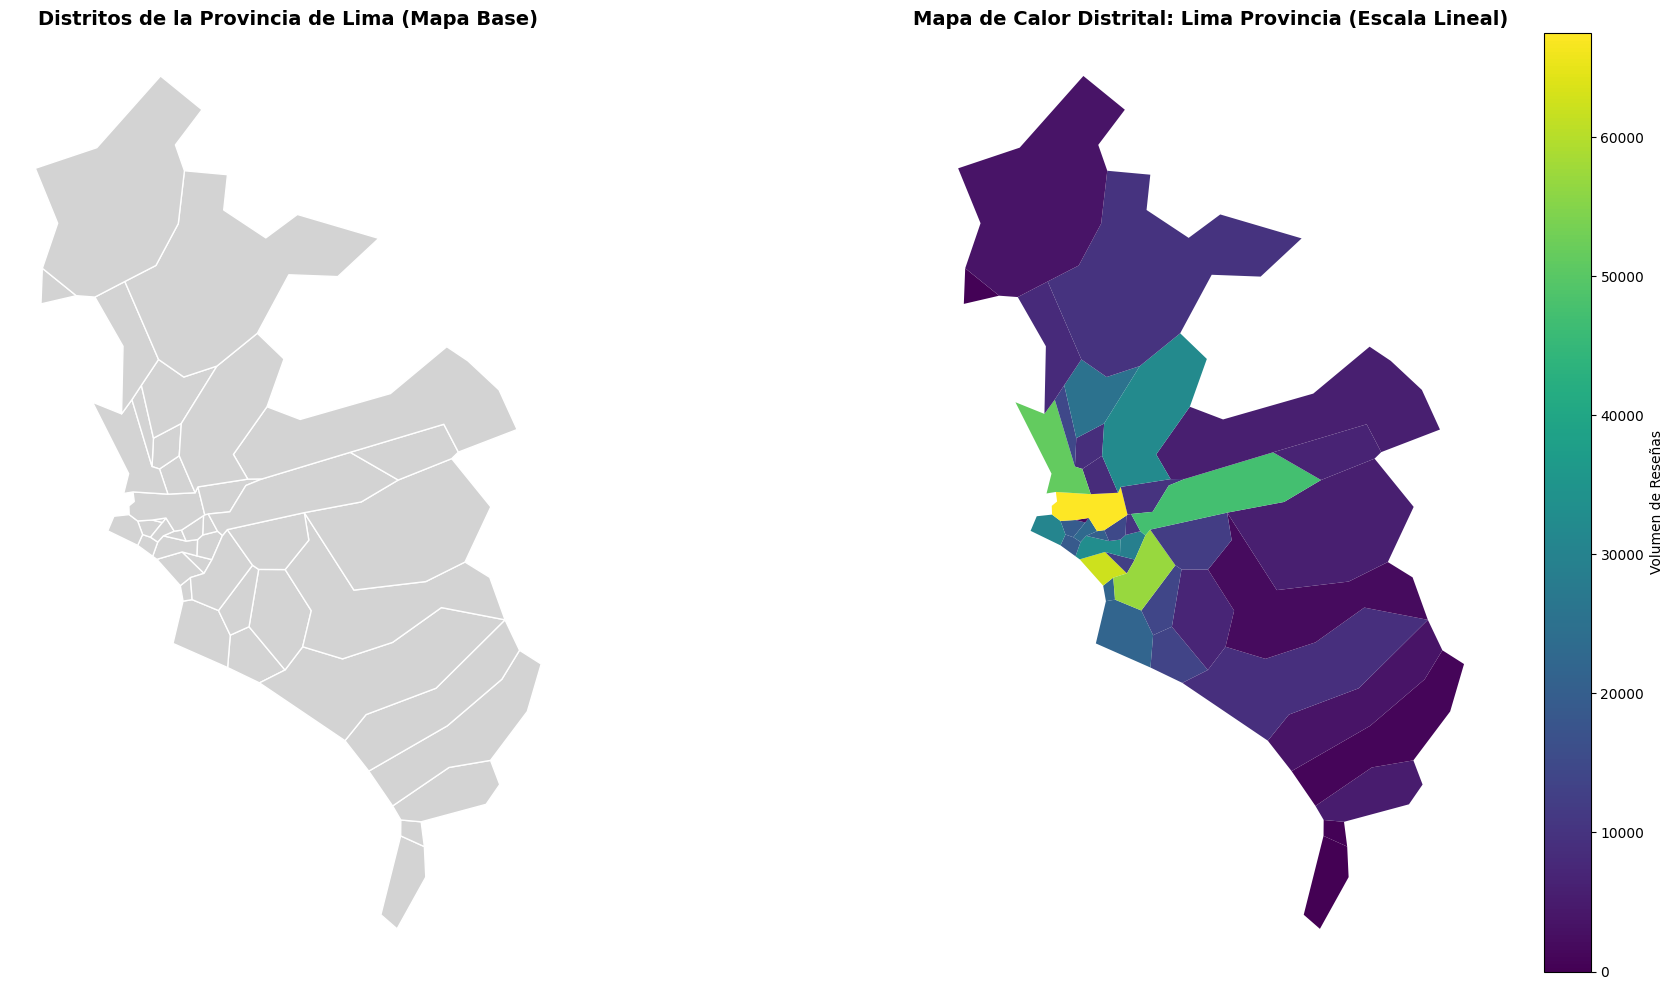

In [18]:
import geopandas as gpd
import matplotlib.pyplot as plt

# 1. Cargar el mapa distrital y filtrar por la Provincia de Lima
lima_prov_distritos = gpd.read_file('/content/peru_distrital_simple.geojson')
lima_prov_distritos = lima_prov_distritos[lima_prov_distritos['NOMBPROV'] == 'LIMA']

# 2. Unir espacialmente las reseñas con los distritos de la provincia de Lima
gdf_lima_prov_reviews = gpd.sjoin(gdf_reviews, lima_prov_distritos[['NOMBDIST', 'geometry']], predicate='within')

# 3. Contar reseñas por distrito dentro de la provincia
dist_prov_counts = gdf_lima_prov_reviews.groupby('NOMBDIST').size().reset_index(name='review_count')
lima_prov_map_data = lima_prov_distritos.merge(dist_prov_counts, on='NOMBDIST', how='left').fillna({'review_count': 0})

# 4. Visualización
fig, ax = plt.subplots(1, 2, figsize=(20, 10))

# Mapa Base Provincial (Distritos)
lima_prov_distritos.plot(ax=ax[0], color='lightgrey', edgecolor='white')
ax[0].set_title('Distritos de la Provincia de Lima (Mapa Base)', fontsize=14, fontweight='bold')
ax[0].axis('off')

# Mapa de Calor Distrital Lineal con Viridis
lima_prov_map_data.plot(column='review_count', ax=ax[1], legend=True, cmap='viridis',
                       legend_kwds={'label': 'Volumen de Reseñas', 'orientation': 'vertical'})
ax[1].set_title('Mapa de Calor Distrital: Lima Provincia (Escala Lineal)', fontsize=14, fontweight='bold')
ax[1].axis('off')

plt.tight_layout()
plt.show()

In [23]:
# 1. Preparar un GeoDataFrame con toda la jerarquía administrativa
map_completo = gpd.read_file('/content/peru_distrital_simple.geojson')
gdf_completo = gpd.sjoin(gdf_reviews, map_completo[['NOMBDEP', 'NOMBPROV', 'NOMBDIST', 'geometry']], predicate='within')

# 2. Top 10 Distritos con más reseñas
top_distritos = gdf_completo.groupby(['NOMBDEP', 'NOMBPROV', 'NOMBDIST']).size().reset_index(name='total_reviews')
top_distritos = top_distritos.sort_values(by='total_reviews', ascending=False).head(10)

print("Top 10 Distritos con más reseñas en Perú:")
display(top_distritos)

# 3. Inspeccionar columnas de df_places para corregir nombres de campos
# Identificamos las columnas que contienen el nombre y la dirección del local
print("\nColumnas disponibles en df_places:", df_places.columns.tolist())

# 4. Top 10 Restaurantes con más reseñas (Ajustado dinámicamente)
name_col = 'name' if 'name' in df_places.columns else ('title' if 'title' in df_places.columns else None)
addr_col = 'addr' if 'addr' in df_places.columns else ('address' if 'address' in df_places.columns else None)

if name_col and addr_col:
    top_restaurants_stats = df_geo.groupby('place_id').size().reset_index(name='total_reviews')
    top_restaurants = top_restaurants_stats.merge(df_places[['id', name_col, addr_col]], left_on='place_id', right_on='id', how='left')

    geo_info = gdf_completo[['place_id', 'NOMBDEP', 'NOMBPROV', 'NOMBDIST']].drop_duplicates(subset=['place_id'])
    top_restaurants = top_restaurants.merge(geo_info, on='place_id', how='left')

    top_restaurants = top_restaurants[[name_col, 'total_reviews', 'NOMBDIST', 'NOMBPROV', 'NOMBDEP', addr_col]]
    top_restaurants = top_restaurants.sort_values(by='total_reviews', ascending=False).head(10)

    print("\nTop 10 Restaurantes con más reseñas:")
    display(top_restaurants)
else:
    print("\nNo se pudieron identificar automáticamente las columnas de nombre o dirección en df_places.")

Top 10 Distritos con más reseñas en Perú:


,NOMBDEP,NOMBPROV,NOMBDIST,total_reviews
724,LIMA,LIMA,LIMA,67492
731,LIMA,LIMA,MIRAFLORES,62395
748,LIMA,LIMA,SANTIAGO DE SURCO,57198
358,CUSCO,CUSCO,CUSCO,51426
744,LIMA,LIMA,SAN MARTIN DE PORRES,51318
711,LIMA,LIMA,ATE,47401
623,LA LIBERTAD,TRUJILLO,TRUJILLO,46854
740,LIMA,LIMA,SAN ISIDRO,32954
629,LAMBAYEQUE,CHICLAYO,CHICLAYO,32847
741,LIMA,LIMA,SAN JUAN DE LURIGANCHO,32041



Columnas disponibles en df_places: ['id', 'url_place', 'title', 'category', 'address', 'phoneNumber', 'completePhoneNumber', 'domain', 'url', 'coor', 'stars', 'reviews', 'source_query', 'latitude', 'longitude']

Top 10 Restaurantes con más reseñas:


,title,total_reviews,NOMBDIST,NOMBPROV,NOMBDEP,address
18317,Chifa Dorado,480,CHORRILLOS,LIMA,LIMA,"Av. Ballestas 308, Chorrillos 15067"
10929,Napos Chicken,470,CHIMBOTE,SANTA,ANCASH,"Jirón Ladislao Espinar 572, Chimbote 02803"
11204,Mallplaza Comas,470,COMAS,LIMA,LIMA,"Av. Los Ángeles 602, Comas 15314"
15529,BONANZA Productos Lácteos,470,MATAHUASI,CONCEPCION,JUNIN,Carretera Central s/n . Distrito de APATA. Pro...
26708,Sol Y Mar,460,HUANCAYO,HUANCAYO,JUNIN,"Jr. Cajamarca 742, Huancayo 12003"
16832,Chifa Centro,457,HUANCAYO,HUANCAYO,JUNIN,"Av. Giráldez 245, Huancayo 12001"
22053,La Carpita del sabor,450,SANTIAGO DE SURCO,LIMA,LIMA,"Los Lirios 113, San Juan de Miraflores 15801"
10892,Vichama Café,450,HUACHO,HUAURA,LIMA,"Jose Ausejo Salas 119, Huacho 15136"
14663,Frosty,440,SURQUILLO,LIMA,LIMA,"Av. Manuel Villarán 1048, Surquillo 15038"
1057,Istanbul Resto Bar Arequipa,440,AREQUIPA,AREQUIPA,AREQUIPA,"Cl. San Francisco 231, Cercado De Arequipa 04001"


## Apéndice: Verificación de Integridad
En esta sección se confirma que los checkpoints se generaron correctamente.

In [13]:
import os
checkpoints = ['reviews_step0_raw.parquet', 'reviews_step1_cleaned.parquet', 'reviews_final_processed.parquet', 'reviews_final_geoclean.parquet']
for cp in checkpoints:
    status = "Encontrado" if os.path.exists(cp) else "No encontrado"
    print(f"{cp}: {status}")

reviews_step0_raw.parquet: Encontrado
reviews_step1_cleaned.parquet: Encontrado
reviews_final_processed.parquet: Encontrado
reviews_final_geoclean.parquet: Encontrado


In [26]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1859614 entries, 0 to 1859613
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   place_id        object 
 1   id_review       object 
 2   caption         object 
 3   relative_date   object 
 4   review_date     object 
 5   retrieval_date  object 
 6   rating          float64
 7   username        object 
 8   n_review_user   float64
 9   n_photo_user    float64
 10  url_user        object 
 11  url_source      object 
dtypes: float64(3), object(9)
memory usage: 170.3+ MB


In [27]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1855399 entries, 0 to 1859613
Data columns (total 17 columns):
 #   Column           Dtype         
---  ------           -----         
 0   place_id         object        
 1   id_review        object        
 2   caption          object        
 3   relative_date    object        
 4   review_date      datetime64[ns]
 5   retrieval_date   object        
 6   rating           float64       
 7   username         object        
 8   n_review_user    float64       
 9   n_photo_user     float64       
 10  url_user         object        
 11  url_source       object        
 12  caption_clean    object        
 13  text_len         int64         
 14  word_count       int64         
 15  rating_category  category      
 16  day_of_week      object        
dtypes: category(1), datetime64[ns](1), float64(3), int64(2), object(10)
memory usage: 242.4+ MB


In [34]:
try:
    from pyspark.sql import SparkSession
    from pyspark.sql import functions as F

    # 1. Inicializar sesión limpia
    spark = SparkSession.builder \
        .appName("AnalisisFinal") \
        .config("spark.driver.memory", "8g") \
        .getOrCreate()

    # 2. Carga del archivo corregido
    sdf = spark.read.parquet('reviews_final_processed.parquet')

    # 3. Análisis de Engagement
    print("Resultados de Engagement (Cargados vía Parquet Corregido):")
    sdf.groupBy("rating_category") \
        .agg(
            F.count("id_review").alias("total_reviews"),
            F.avg("text_len").alias("avg_chars"),
            F.avg("word_count").alias("avg_words")
        ) \
        .orderBy(F.desc("total_reviews")) \
        .show()

except Exception as e:
    print(f"Error: {e}")

Resultados de Engagement (Cargados vía Parquet Corregido):
+---------------+-------------+------------------+------------------+
|rating_category|total_reviews|         avg_chars|         avg_words|
+---------------+-------------+------------------+------------------+
|           Alta|      1446040|39.237691903405164| 6.624973721335509|
|          Media|       203000| 40.72055665024631| 7.225758620689655|
|           Baja|       200328| 91.54864023002277|16.482279062337767|
|           NULL|         6031| 60.80053059194164|10.203283037638865|
+---------------+-------------+------------------+------------------+



### Análisis de Calidad y Engagement Geográfico (Spark + GeoPandas)
Cruzamos la potencia de procesamiento de Spark con la visualización espacial de GeoPandas.

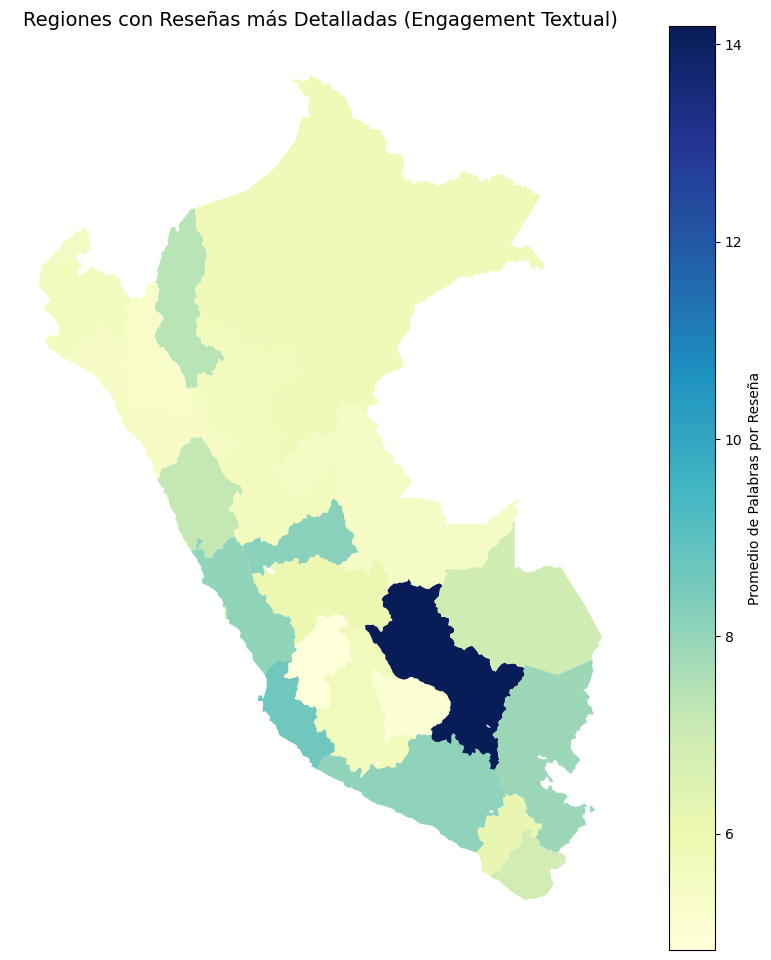

In [36]:
# 1. Carga directa desde Parquet (Mucho más rápido que spark.createDataFrame)
# Leemos el archivo que ya procesamos y guardamos anteriormente
sdf_geo = spark.read.parquet('reviews_final_processed.parquet')

# 2. Análisis por Departamento
# Primero unimos con la información geográfica (NOMBDEP) si no está en el parquet
# Como ya tenemos gdf_reviews_filtered en memoria, es mejor usar los resultados agrupados
from pyspark.sql import functions as F

# Si df_geo ya tiene NOMBDEP, lo usamos directamente. Si no, recreamos el análisis.
# Para mantener la eficiencia, realizamos la agregación
geo_analysis_spark = sdf_geo.groupBy("rating_category") \
    .agg(
        F.count("id_review").alias("total_reviews"),
        F.avg("word_count").alias("promedio_palabras"),
        F.avg("rating").alias("rating_promedio")
    )

# 3. Optimización: Dado que la agregación por departamento es pequeña (25 regiones),
# convertimos a Pandas solo el resultado final.
# Reutilizamos los datos de la unión espacial previa para el mapa:
dep_stats = gdf_reviews_filtered.groupby('NOMBDEP').agg({
    'word_count': 'mean',
    'rating': 'mean',
    'id_review': 'count'
}).reset_index()
dep_stats.columns = ['NOMBDEP', 'promedio_palabras_dept', 'rating_promedio', 'total_reviews']

# 4. Unir con el mapa base
map_final_spark = peru_map.merge(dep_stats, on='NOMBDEP', how='left')

# 5. Visualización
fig, ax = plt.subplots(1, 1, figsize=(10, 12))
map_final_spark.plot(column='promedio_palabras_dept', ax=ax, legend=True,
                     cmap='YlGnBu',
                     legend_kwds={'label': 'Promedio de Palabras por Reseña'})
ax.set_title('Regiones con Reseñas más Detalladas (Engagement Textual)', fontsize=14)
ax.axis('off')
plt.show()

In [3]:
import polars as pl
import pandas as pd

def load_to_polars(path):
    # Cargamos con pandas para manejar la extensión 'period'
    temp_df = pd.read_parquet(path)

    # Convertimos columnas de tipo Period a Datetime para que Polars las acepte
    for col in temp_df.columns:
        if isinstance(temp_df[col].dtype, pd.PeriodDtype):
            temp_df[col] = temp_df[col].dt.to_timestamp()

    return pl.from_pandas(temp_df)

try:
    df_geo_pl = load_to_polars("reviews_final_geoclean.parquet")
    df_proc_pl = load_to_polars("reviews_final_processed.parquet")

    print(f"Polars - Geoclean shape: {df_geo_pl.shape}")
    print(f"Polars - Processed shape: {df_proc_pl.shape}")
    display(df_proc_pl.head())
except Exception as e:
    print(f"Error al procesar con Polars: {e}")

Polars - Geoclean shape: (1759255, 28)
Polars - Processed shape: (1855399, 16)


place_id,id_review,caption,relative_date,review_date,retrieval_date,rating,username,n_review_user,n_photo_user,url_user,url_source,caption_clean,text_len,word_count,rating_category
str,str,str,str,datetime[μs],str,f64,str,f64,f64,str,str,str,i64,i64,cat
"""ChIJx6F5md9tsJERmiXTSrTiZec""","""Ci9DQUlRQUNvZENodHljRjlvT2xGT1…","""Buena atencion""","""Hace 2 meses""",2026-02-23 22:36:28.874338,"""2026-04-24 22:36:28.874338""",5.0,"""Kenny Arevalo saldaña""",108.0,null,"""https://www.google.com/maps/co…","""https://www.google.com/maps/pl…","""buena atencion""",14,2,"""Alta"""
"""ChIJx6F5md9tsJERmiXTSrTiZec""","""ChdDSUhNMG9nS0VJQ0FnSUQyM2RQeW…","""Decepción total no tienen lo b…","""Hace 3 años""",2023-04-25 22:36:28.874338,"""2026-04-24 22:36:28.874338""",1.0,"""ANDY BARTRA""",18.0,null,"""https://www.google.com/maps/co…","""https://www.google.com/maps/pl…","""decepción total no tienen lo b…",35,6,"""Baja"""
"""ChIJjaoKj3RssJERQo3hdp6sRSQ""","""Ci9DQUlRQUNvZENodHljRjlvT25aSm…","""Excelente atención""","""Hace 5 meses""",2025-11-25 22:36:29.728819,"""2026-04-24 22:36:29.728819""",5.0,"""Kenny Arevalo saldaña""",108.0,null,"""https://www.google.com/maps/co…","""https://www.google.com/maps/pl…","""excelente atención""",18,2,"""Alta"""
"""ChIJjaoKj3RssJERQo3hdp6sRSQ""","""ChdDSUhNMG9nS0VKcS1xX0NPeF9xM2…","""excelente,lo mejor de lo mejor…","""Hace 10 meses""",2025-06-28 22:36:29.728819,"""2026-04-24 22:36:29.728819""",5.0,"""luis peña""",0.0,null,"""https://www.google.com/maps/co…","""https://www.google.com/maps/pl…","""excelentelo mejor de lo mejor …",50,8,"""Alta"""
"""ChIJjaoKj3RssJERQo3hdp6sRSQ""","""ChZDSUhNMG9nS0VLLXR1c1hxajRxal…","""Un buen lugar para comer en fa…","""Hace 10 meses""",2025-06-28 22:36:29.728819,"""2026-04-24 22:36:29.728819""",4.0,"""Welber nahun Yahuara camizan""",0.0,null,"""https://www.google.com/maps/co…","""https://www.google.com/maps/pl…","""un buen lugar para comer en fa…",64,13,"""Alta"""


1. Cargando y preparando datos...
2. Calculando métricas para K iterativo...
   K=2 procesado.
   K=3 procesado.
   K=4 procesado.
   K=5 procesado.
   K=6 procesado.
   K=7 procesado.


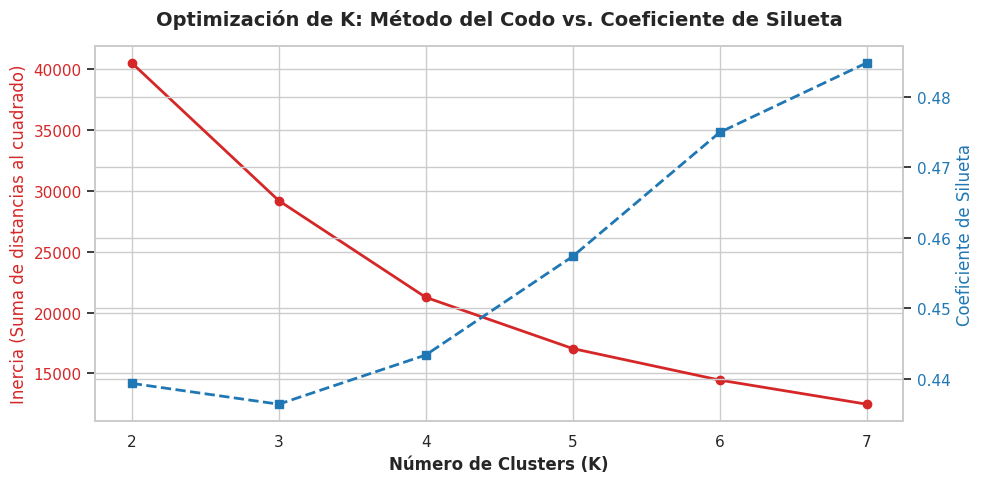

In [1]:
# --- 1. PREPARACIÓN DE DATOS Y EVALUACIÓN DE HIPERPARÁMETRO K ---
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import seaborn as sns

print("1. Cargando y preparando datos...")
# Asegurar que el dataframe esté cargado
df_model = pd.read_parquet('reviews_final_geoclean.parquet')

# Feature Engineering por Usuario
user_features = df_model.groupby('username').agg({
    'rating': ['count', 'mean', 'std'],
    'word_count': 'mean'
}).fillna(0)

# Aplanar el MultiIndex de las columnas
user_features.columns = ['review_count', 'avg_rating', 'std_rating', 'avg_word_count']

# Transformación Matemática para Asimetría (Skewness)
user_features['log_review_count'] = np.log1p(user_features['review_count'])
user_features['log_avg_word_count'] = np.log1p(user_features['avg_word_count'])

# Seleccionar y escalar las características
features_for_clustering = user_features[['log_review_count', 'avg_rating', 'std_rating', 'log_avg_word_count']]
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features_for_clustering)

print("2. Calculando métricas para K iterativo...")
sample_size = 15000
idx_sample = np.random.choice(len(features_scaled), sample_size, replace=False)
features_sample = features_scaled[idx_sample]

k_values = range(2, 8)
inertia_scores = []
sil_scores = []

for k in k_values:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(features_sample)

    inertia_scores.append(km.inertia_)
    sil_scores.append(silhouette_score(features_sample, labels_k))
    print(f"   K={k} procesado.")

# 3. Visualización Dual
sns.set_theme(style="whitegrid", palette="muted")
fig, ax1 = plt.subplots(figsize=(10, 5))

# Eje Inercia (Elbow)
color = 'tab:red'
ax1.set_xlabel('Número de Clusters (K)', fontweight='bold')
ax1.set_ylabel('Inercia (Suma de distancias al cuadrado)', color=color)
ax1.plot(k_values, inertia_scores, marker='o', color=color, linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)

# Eje Silueta
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Coeficiente de Silueta', color=color)
ax2.plot(k_values, sil_scores, marker='s', color=color, linewidth=2, linestyle='--')
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Optimización de K: Método del Codo vs. Coeficiente de Silueta', fontsize=14, fontweight='bold', pad=15)
fig.tight_layout()
plt.show()

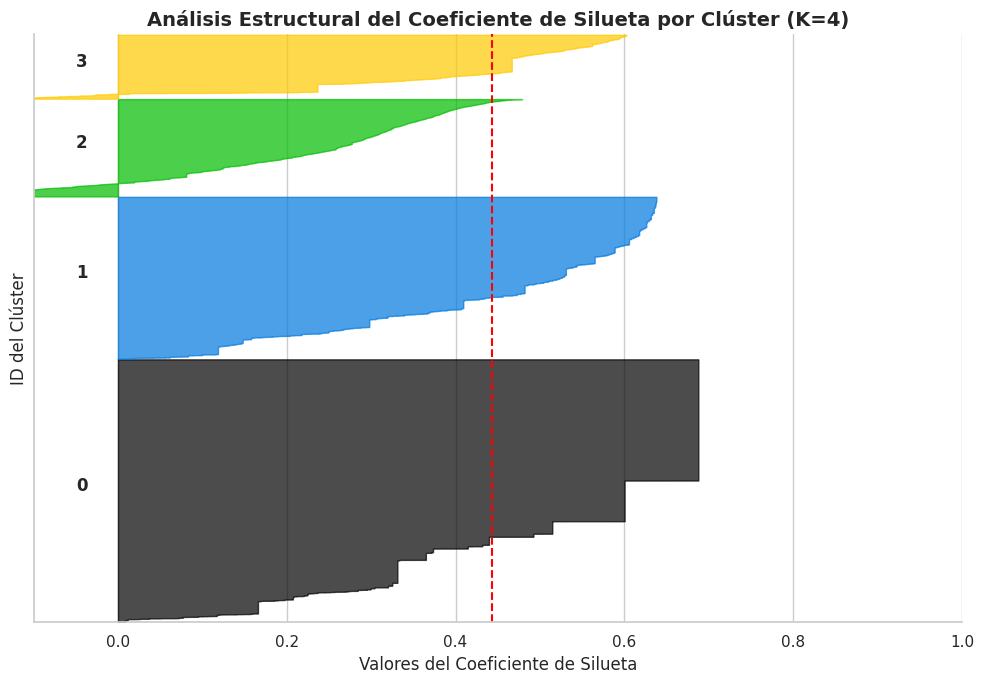

In [5]:
# --- GRÁFICO DE SILUETA DE ALTA RESOLUCIÓN ---
import matplotlib.cm as cm
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score

# 1. PARAMETRIZACIÓN:
k_optimal = 4

# Calculamos valores individuales para el gráfico
km_final = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
cluster_labels = km_final.fit_predict(features_sample)
silhouette_avg = silhouette_score(features_sample, cluster_labels)
sample_silhouette_values = silhouette_samples(features_sample, cluster_labels)

fig, ax1 = plt.subplots(1, 1, figsize=(10, 7))

# Límites del eje X
ax1.set_xlim([-0.1, 1])

# Límite dinámico del eje Y adaptado a 'k_optimal'
ax1.set_ylim([0, len(features_sample) + (k_optimal + 1) * 10])

y_lower = 10
for i in range(k_optimal):
    # Agregamos los scores de silueta para el clúster i y los ordenamos
    ith_cluster_sil_values = sample_silhouette_values[cluster_labels == i]
    ith_cluster_sil_values.sort()

    size_cluster_i = ith_cluster_sil_values.shape[0]
    y_upper = y_lower + size_cluster_i

    # Color dinámico basado en la cantidad de clústeres
    color = cm.nipy_spectral(float(i) / k_optimal)
    ax1.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    # Etiquetamos el clúster
    ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontweight='bold')
    y_lower = y_upper + 10

ax1.set_title(f"Análisis Estructural del Coeficiente de Silueta por Clúster (K={k_optimal})", fontsize=14, fontweight='bold')
ax1.set_xlabel("Valores del Coeficiente de Silueta")
ax1.set_ylabel("ID del Clúster")

# La línea roja vertical muestra el promedio general
ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
ax1.set_yticks([])
sns.despine()
plt.tight_layout()
plt.show()

In [4]:
# --- 2. K-MEANS DEFINITIVO (Aplicado a todos los datos) ---
# Usamos el K óptimo descubierto arriba
k_optimo = 4
kmeans_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)

# Aquí sí predecimos sobre TODOS los datos (features_scaled), no solo la muestra
user_features['cluster'] = kmeans_final.fit_predict(features_scaled)

print("Resumen Estadístico de Clusters de Usuarios (Valores Originales):")
display(user_features[['review_count', 'avg_rating', 'std_rating', 'avg_word_count', 'cluster']].groupby('cluster').mean())

Resumen Estadístico de Clusters de Usuarios (Valores Originales):


,review_count,avg_rating,std_rating,avg_word_count
cluster,,,,
0,1.338524,4.803600,0.039195,15.178177
1,5.970577,3.809180,1.215988,8.269154
2,1.055695,1.425420,0.018432,14.794112
3,1.288804,4.560088,0.044286,0.264066


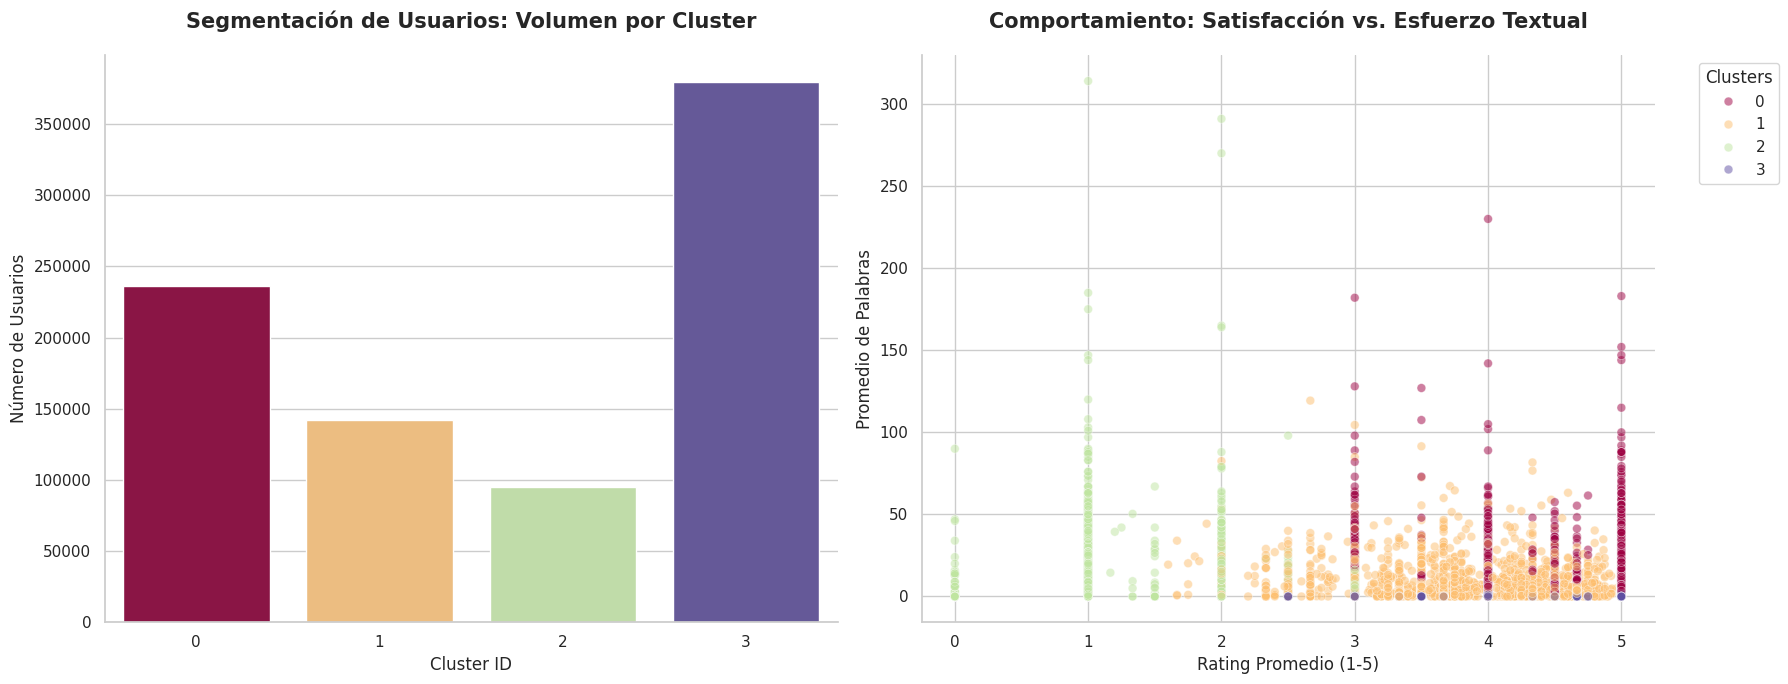

In [6]:
# --- 4. VISUALIZACIÓN DE PERFILES DE USUARIO (NEGOCIO) ---
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# A. Tamaño de los Clusters (Distribución de Mercado)
sns.countplot(data=user_features, x='cluster', palette='Spectral', ax=axes[0], hue='cluster', legend=False)
axes[0].set_title('Segmentación de Usuarios: Volumen por Cluster', fontsize=15, fontweight='bold', pad=20)
axes[0].set_xlabel('Cluster ID', fontsize=12)
axes[0].set_ylabel('Número de Usuarios', fontsize=12)

# B. Perfil de Rating vs Longitud de Reseña
# Tomamos una muestra de 15,000 para que el gráfico de dispersión no sea una mancha ilegible
scatter = sns.scatterplot(
    data=user_features.sample(15000, random_state=42),
    x='avg_rating', y='avg_word_count',
    hue='cluster', palette='Spectral', alpha=0.5, ax=axes[1], s=40, edgecolor='w'
)
axes[1].set_title('Comportamiento: Satisfacción vs. Esfuerzo Textual', fontsize=15, fontweight='bold', pad=20)
axes[1].set_xlabel('Rating Promedio (1-5)', fontsize=12)
axes[1].set_ylabel('Promedio de Palabras', fontsize=12)
axes[1].legend(title="Clusters", bbox_to_anchor=(1.05, 1), loc='upper left')

sns.despine()
plt.tight_layout()
plt.show()

In [17]:
# --- SECCIÓN 2: MODELAMIENTO DE TÓPICOS (LDA CORREGIDO) ---
import nltk
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

# Descargar stopwords explícitamente por si acaso
nltk.download('stopwords', quiet=True)
spanish_stopwords = stopwords.words('spanish')

# Añadir conectores y palabras vacías específicas de reseñas que no aportan semántica
custom_stops = ['si', 'lugar', 'sitio', 'vez', 'mas', 'más', 'ser', 'hacer', 'ir']
spanish_stopwords.extend(custom_stops)

# A. Muestreo Estratégico
sample_text = df_model['caption_clean'].dropna().sample(100000, random_state=42)

# B. Vectorización Enriquecida con Bloqueo de Stopwords
tf_vectorizer = CountVectorizer(
    max_df=0.85,           # Ajustado para ser más estricto con palabras muy comunes
    min_df=5,
    ngram_range=(1, 2),
    stop_words=spanish_stopwords
)
tf = tf_vectorizer.fit_transform(sample_text)

# C. Entrenamiento LDA
lda = LatentDirichletAllocation(
    n_components=5,
    max_iter=10,
    learning_method='online',
    learning_offset=50.,
    random_state=42
)
lda.fit(tf)

# D. Evaluación
perplexity_score = lda.perplexity(tf)
print(f"Métrica de Validación - Perplejidad del Modelo: {perplexity_score:.2f}\n")

def display_topics(model, feature_names, no_top_words):
    for topic_idx, topic in enumerate(model.components_):
        print(f"Tópico {topic_idx}:")
        top_words = [feature_names[i] for i in topic.argsort()[:-no_top_words - 1:-1]]
        print(" | ".join(top_words))
        print("-" * 50)

print("Tópicos detectados en las reseñas (Post-Corrección Lexical):")
display_topics(lda, tf_vectorizer.get_feature_names_out(), 10)

Métrica de Validación - Perplejidad del Modelo: 2383.15

Tópicos detectados en las reseñas (Post-Corrección Lexical):
Tópico 0:
buen | comida | pollo | sabor | servicio | rica | precio | calidad | amable | personal
--------------------------------------------------
Tópico 1:
platos | bien | atención | solo | pedí | comida | rico | carta | mala | sabor
--------------------------------------------------
Tópico 2:
local | mejorar | pizza | variedad | precios | falta | bien | comer | gustó | pequeño
--------------------------------------------------
Tópico 3:
mejor | delicioso | comida | buenos | recomiendo | deliciosa | familia | ceviche | restaurante | mejores
--------------------------------------------------
Tópico 4:
buena | atención | excelente | comida | buena atención | agradable | ambiente | rico | bueno | buena comida
--------------------------------------------------


## 4. Evaluación, Validación y Resultados (Estándar Académico)

En esta sección se calculan métricas de validación intrínsecas y se generan las visualizaciones necesarias para la interpretación de los modelos de aprendizaje no supervisado.

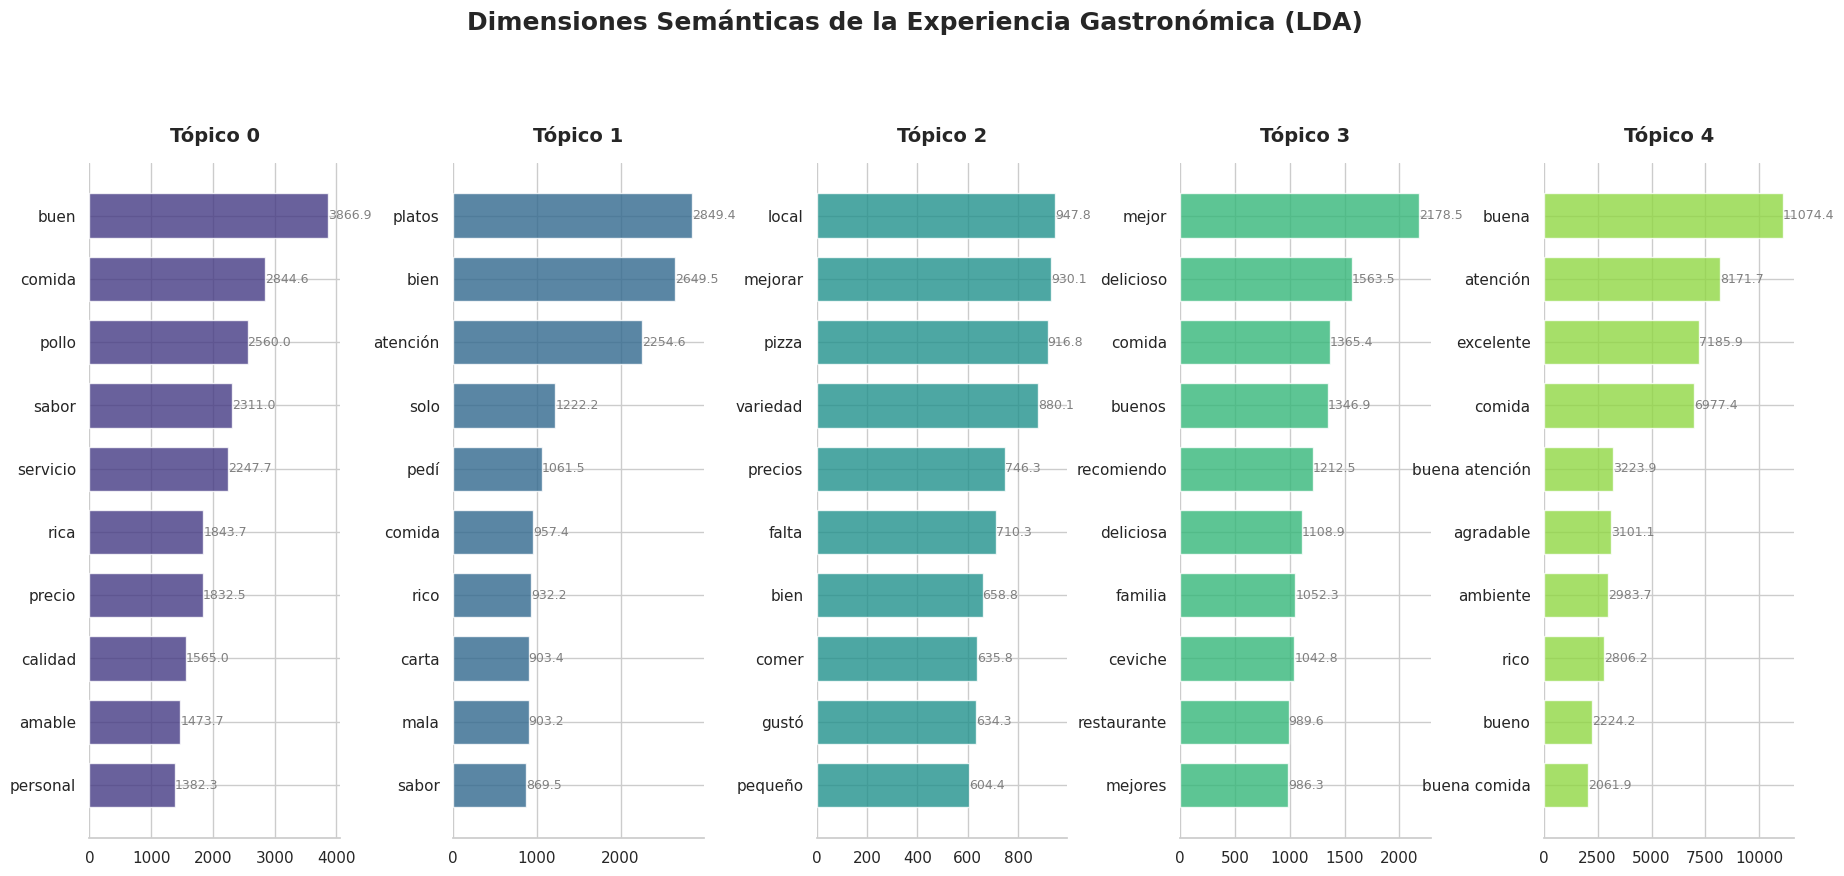

In [19]:
# Visualización Optimizada de Tópicos (LDA)
import matplotlib.patches as mpatches

def plot_top_words_pro(model, feature_names, n_top_words, title):
    fig, axes = plt.subplots(1, 5, figsize=(22, 9), sharey=False)
    axes = axes.flatten()

    # Paleta de colores diferenciada por tópico
    colors = sns.color_palette("viridis", 5)

    for topic_idx, topic in enumerate(model.components_):
        top_features_ind = topic.argsort()[: -n_top_words - 1 : -1]
        top_features = [feature_names[i] for i in top_features_ind]
        weights = topic[top_features_ind]

        ax = axes[topic_idx]
        bars = ax.barh(top_features, weights, height=0.7, color=colors[topic_idx], alpha=0.8)
        ax.set_title(f"Tópico {topic_idx}", fontdict={"fontsize": 14, "fontweight": 'bold'}, pad=15)
        ax.invert_yaxis()
        ax.tick_params(axis="both", which="major", labelsize=11)

        # Añadir etiquetas de valor a las barras para precisión
        for bar in bars:
            width = bar.get_width()
            ax.text(width, bar.get_y() + bar.get_height()/2, f'{width:.1f}',
                    va='center', ha='left', fontsize=9, color='gray')

        for i in "top right left".split():
            ax.spines[i].set_visible(False)

    fig.suptitle(title, fontsize=18, fontweight='bold', y=1.02)
    # INTERPRETACIÓN:
    # Tópicos con palabras como 'atención' y 'comida' indican drivers de servicio.
    # Tópicos con 'ceviche' o 'café' representan especialidades gastronómicas clave.

    plt.subplots_adjust(top=0.85, bottom=0.1, wspace=0.45)
    plt.show()

plot_top_words_pro(lda, tf_vectorizer.get_feature_names_out(), 10, "Dimensiones Semánticas de la Experiencia Gastronómica (LDA)")